# Systematic Option Strategies on Crypto
### Replicating Lucic & Sepp (2024) on ETH/BTC Deribit data — construction, backtest, and diagnosis

**Natixis CIB — Quant Analyst Internship**

---

Companion to `project_outline.ipynb`. That one documents the **surface-fitting library** —
cleaning Deribit quotes, calibrating SVI/SSVI/eSSVI/SABR, arbitrage checks, the live
screen. This one documents the **strategies built on top of it**: how they are
constructed, how the backtester works, what they returned, and why.

Headline: **two strategy families, 26 systematic variants, no positive Sharpe.** The
second half of the notebook is the diagnosis, which is where the useful findings are.

By the end you will be able to:

1. Build any structure in the catalogue and see how it resolves to tradeable instruments.
2. Explain why a coin-settled inverse option needs a **premium-adjusted delta**, and what
   breaks without it.
3. Follow the backtester's full state machine — open → accrue → mark → rehedge → settle.
4. Account for a strategy in **coin or USD**, and know why that changes beta and not much else.
5. Read the paper-style results table and the attribution behind it.
6. Explain why delta-hedging leaves a **residual directional beta**, and trace it to vanna.

> **Runtime note.** ~70 seconds. Sections marked **[archive]** need the full options
> archive (`clean_chunks_full`, `eth_hourly_2024.parquet`), which lives on the desk
> machine; those report recorded results. Everything else recomputes live from the perp.

## Table of contents

0. [Environment setup](#sec0)
1. [Two strategy families](#sec1)
2. [The structure catalogue](#sec2)
3. [The roll calendar](#sec3)
4. [From structure to instrument: leg selection](#sec4)
5. [Inverse options: payoff, and the hedge ratio](#sec5)
6. [The backtest state machine](#sec6)
7. [Execution, costs and funding](#sec7)
8. [Accounting and position sizing](#sec8)
9. [The relative-value engine: red cells](#sec9)
10. [Results](#sec10)
11. [Diagnosis I — the strategies traded direction](#sec11)
12. [Diagnosis II — which volatility does a hedger earn?](#sec12)
13. [Diagnosis III — the spot–vol correlation](#sec13)
14. [Regimes, and a look-ahead trap](#sec14)
15. [Trials & errors](#sec15)
16. [Conclusion](#sec16)

<a id="sec0"></a>
## 0. Environment setup

In [1]:
import sys, warnings, inspect
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 40); pd.set_option("display.width", 200)
plt.rcParams.update({"figure.facecolor": "white", "axes.grid": True,
                     "grid.alpha": 0.3, "figure.dpi": 110})

here = Path.cwd()
PROJECT_ROOT = next((p for p in [here, *here.parents] if (p / "2 - Data").exists()), here)
if str(PROJECT_ROOT) not in sys.path: sys.path.insert(0, str(PROJECT_ROOT))
PERP   = str(PROJECT_ROOT / "2 - Data" / "parquets" / "eth_perp_1min_2024_2026.parquet")
CHUNKS = PROJECT_ROOT / "volatility_surface" / "notebooks" / "clean_chunks_full"
RESULTS = PROJECT_ROOT / "results"
print("Project root:", PROJECT_ROOT)
print("perp                 :", Path(PERP).exists())
print("options archive here :", CHUNKS.exists(), " <- [archive] sections need this")

Project root: /Users/macbookair/Internship Natixis
perp                 : True
options archive here : False  <- [archive] sections need this


In [2]:
from volatility_surface.backtest import roll_engine as R
from volatility_surface.backtest import roll_results as RR
from volatility_surface.backtest import signal as SIG
from volatility_surface.backtest import leverage as LEV
from volatility_surface.backtest import spot_vol_corr as SV
from volatility_surface.backtest import vrp_signal as V
from volatility_surface.core.pricing.pricing_models import (
    inverse_delta, gk_delta, gk_price, gk_vega, gk_vanna)
from volatility_surface.plots.vol_plots import PALETTE

perp = pd.read_parquet(PERP, columns=["timestamp_ms", "close"])
perp.index = pd.to_datetime(perp["timestamp_ms"], unit="ms", utc=True)
spot = perp["close"].resample("1D").last().dropna()
print(f"{len(R.catalog_names())} strategies in the catalogue")
print(f"perp: {len(perp):,} 1-min bars, {perp.index[0]:%Y-%m-%d} -> {perp.index[-1]:%Y-%m-%d}")

26 strategies in the catalogue
perp: 1,142,674 1-min bars, 2024-06-01 -> 2026-08-03


<a id="sec1"></a>
## 1. Two strategy families

The project implements two genuinely different things, in two engines that share pricing
but nothing else.

| | `backtest/roll_engine.py` (793 lines) | `backtest/engine.py` (561 lines) |
|---|---|---|
| **idea** | **systematic** — fixed calendar, fixed structure | **opportunistic relative value** |
| **source** | Lucic & Sepp (2024) §5.2–5.3 | our own, from the live screen's red cells |
| **entry** | every roll date, unconditionally | when the calibrated surface disagrees with the book |
| **selection** | ATM / 25Δ / 10Δ by rule | whichever cells are flagged |
| **exit** | held to maturity | signal nulls out, better cell appears, or expiry |
| **sizing** | contracts ∝ Coin NAV | vega-targeted ($1,000 vega per position) |
| **hedge** | hourly, perp, Net Delta | same |
| **surface** | not needed — trades listed strikes | full eSSVI recalibrated every 15 min |

Both hedge with `inverse_delta` (§5). §2–8 cover the systematic engine; §9 covers the
relative-value one.

The economic case for the systematic family is the **volatility risk premium**: implied
vol usually exceeds subsequent realised vol, so selling vol and hedging the delta should
earn the difference. Whether that premium exists in ETH is §11.3.

<a id="sec2"></a>
## 2. The structure catalogue

A leg is `(moneyness, option_type, qty)`. `qty` is the signed unit count of the **long**
version; the short variant is every `qty` negated. `moneyness` is either `"ATM"` or
`("delta", d)`. Contracts per leg = `qty × N`, with `N` the current Coin NAV.

In [3]:
base = R._BASE_STRUCTURES
rows = []
for name, legs in base.items():
    rows.append({"structure": name, "legs": len(legs),
                 "definition (long side)": ", ".join(
                     f"{q:+g}x {'ATM' if m=='ATM' else f'{m[1]:.0%}D'} {o}" for m, o, q in legs)})
print(f"{len(base)} base structures x Long/Short = {len(R.build_catalog())} strategies\n")
pd.DataFrame(rows).set_index("structure")

13 base structures x Long/Short = 26 strategies



,legs,definition (long side)
structure,,
ATM Call,1,+1x ATM C
25D Call,1,+1x 25%D C
10D Call,1,+1x 10%D C
ATM Put,1,+1x ATM P
25D Put,1,+1x 25%D P
10D Put,1,+1x 10%D P
Straddle,2,"+1x ATM C, +1x ATM P"
25D Strangle,2,"+1x 25%D C, +1x 25%D P"
10D Strangle,2,"+1x 10%D C, +1x 10%D P"


Single-leg structures are the paper's Tables 1–2; multi-leg are Tables 3–5.

The spreads and the risk reversal are the interesting ones: they isolate **skew** rather
than level. A `Call Spread` is short 1× 50Δ call, long 2× 25Δ call — a bet on the call
wing's shape, not on whether vol is high. `25D ButterFly` is long the ATM straddle and
short the 25Δ strangle, i.e. long implied convexity.

In [4]:
cat = R.build_catalog()
for nm in ["Short Straddle", "Long 25D Strangle", "Short 25D RR", "Long 25D ButterFly"]:
    print(f"{nm:22s} {cat[nm]}")

Short Straddle         [('ATM', 'C', -1.0), ('ATM', 'P', -1.0)]
Long 25D Strangle      [(('delta', 0.25), 'C', 1.0), (('delta', 0.25), 'P', 1.0)]
Short 25D RR           [(('delta', 0.25), 'P', 1.0), (('delta', 0.25), 'C', -1.0)]
Long 25D ButterFly     [('ATM', 'C', 1.0), ('ATM', 'P', 1.0), (('delta', 0.25), 'C', -1.0), (('delta', 0.25), 'P', -1.0)]


<a id="sec3"></a>
## 3. The roll calendar

Deribit weeklies expire **Friday 08:00 UTC**. Rolling at that instant into the following
Friday's expiry is a clean, non-overlapping hand-off: the old structure settles and the
new one opens in the same event, so the book is never double-exposed.

In [5]:
lo, hi = int(perp["timestamp_ms"].iloc[0]), int(perp["timestamp_ms"].iloc[-1])
for freq in ("daily", "weekly", "monthly", "quarterly"):
    g = R.roll_grid(lo, hi, freq)
    d = pd.to_datetime(pd.Series(g), unit="ms", utc=True)
    print(f"{freq:10s} {len(g):4d} rolls | first {d.iloc[0]:%Y-%m-%d %H:%M} | "
          f"last {d.iloc[-1]:%Y-%m-%d %H:%M} | median gap {d.diff().median()}")

daily       794 rolls | first 2024-06-01 08:00 | last 2026-08-03 08:00 | median gap 1 days 00:00:00
weekly      113 rolls | first 2024-06-07 08:00 | last 2026-07-31 08:00 | median gap 7 days 00:00:00
monthly      26 rolls | first 2024-06-28 08:00 | last 2026-07-31 08:00 | median gap 28 days 00:00:00
quarterly     9 rolls | first 2024-06-28 08:00 | last 2026-06-26 08:00 | median gap 91 days 00:00:00


Monthly and quarterly use the **last** Friday of the month/quarter, matching Deribit's
listed expiries. Daily exists because Deribit lists ~4 consecutive dailies at the front,
verified on real chain data.

<a id="sec4"></a>
## 4. From structure to instrument: leg selection

`_select_leg` turns `("delta", 0.25), "C"` into an actual instrument. The rule follows
§5.3 of the paper:

- **ATM** — the two strikes nearest the forward, then whichever has **maximum open
  interest** ("adjacent strike with maximum open interest").
- **(delta, d)** — among that option type's strikes, the two whose |Black delta| bracket
  `d`, then again max open interest.

The delta used for selection comes from **each strike's own mid IV**, not from a fitted
surface. That is deliberate: the paper leaves Deribit-vs-Black delta open, and using the
raw quote keeps selection independent of whether our calibration is good that day.

Tie-breaking on open interest matters more than it looks — the nearest strike is often
barely quoted, and picking it would produce fills that never existed.

In [6]:
# a synthetic one-expiry chain, to show the selection rule without needing the archive
F, T = 3000.0, 7/365
strikes = np.arange(2400, 3700, 100.0)
chain = pd.DataFrame({
    "strike": np.r_[strikes, strikes],
    "option_type": ["C"]*len(strikes) + ["P"]*len(strikes),
    "t": T, "underlying_price": F,
})
chain["mid_iv"] = 0.65 + 0.25*(np.log(chain["strike"]/F))**2
chain["bid_iv"] = chain["mid_iv"] - 0.01; chain["ask_iv"] = chain["mid_iv"] + 0.01
rng = np.random.default_rng(0)
chain["open_interest"] = rng.integers(10, 900, len(chain))
chain["instrument_id"] = [f"ETH-{int(k)}-{o}" for k, o in zip(chain.strike, chain.option_type)]

for mny, ot, lbl in [("ATM","C","ATM call"), (("delta",0.25),"C","25D call"),
                     (("delta",0.10),"P","10D put")]:
    leg = R._select_leg(chain, F, mny, ot)
    d = gk_delta(1.0, leg["strike"]/F, T, 0, 0, leg["mid_iv"], "c" if ot=="C" else "p")
    print(f"{lbl:10s} -> K={leg['strike']:.0f}  (K/F={leg['strike']/F:.3f})  "
          f"Black delta={d:+.3f}  OI={leg['open_interest']}")

ATM call   -> K=3000  (K/F=1.000)  Black delta=+0.518  OI=76
25D call   -> K=3300  (K/F=1.100)  Black delta=+0.156  OI=733
10D put    -> K=2600  (K/F=0.867)  Black delta=-0.052  OI=659


<a id="sec5"></a>
## 5. Inverse options: payoff, and the hedge ratio

This is the part of the implementation that most changes the results.

### 5.1 The payoff is denominated in coin

Deribit options are **inverse**: quoted and settled in BTC/ETH, not USD. Settlement is

$$\text{payoff}_{\text{coin}} = \frac{(S_T-K)^+}{S_T}\ \text{(call)},\qquad
\frac{(K-S_T)^+}{S_T}\ \text{(put)}$$

That $1/S_T$ makes the coin payoff **non-linear in spot even after expiry is fixed** — and
asymmetric between calls and puts.

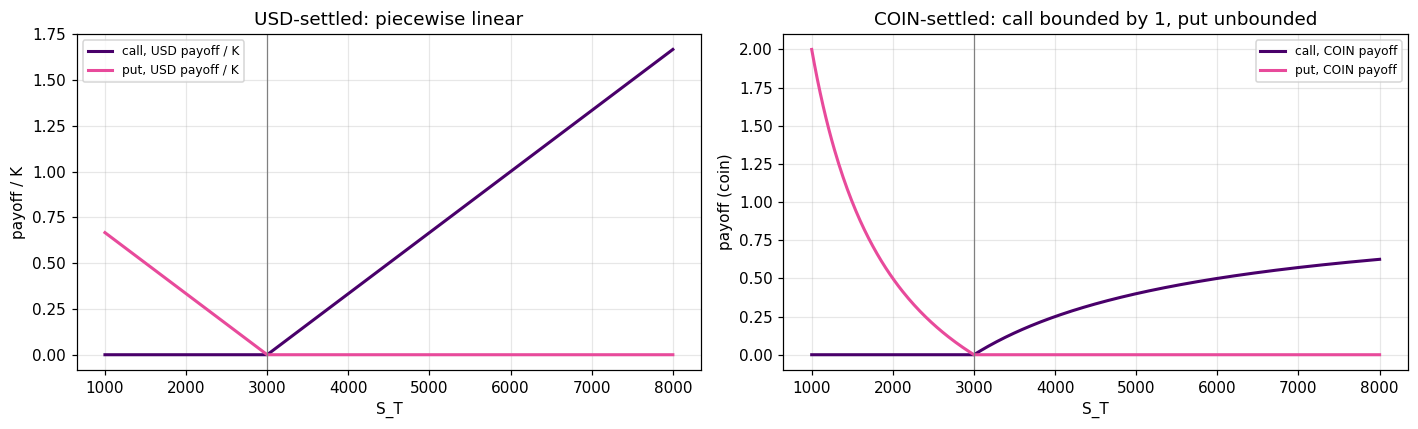

call coin payoff -> 0.625 at S_T=8000   (asymptote 1: 1 - K/S)
put  coin payoff -> 2.000 at S_T=1000   (K/S - 1, unbounded as S->0)


In [7]:
S = np.linspace(1000, 8000, 400); K = 3000.0
call_usd = np.maximum(S-K, 0); put_usd = np.maximum(K-S, 0)
call_coin = np.array([R._coin_payoff("C", K, s) for s in S])
put_coin  = np.array([R._coin_payoff("P", K, s) for s in S])

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].plot(S, call_usd/K, color=PALETTE[7], lw=2, label="call, USD payoff / K")
ax[0].plot(S, put_usd/K,  color=PALETTE[3], lw=2, label="put, USD payoff / K")
ax[0].set(xlabel="S_T", ylabel="payoff / K", title="USD-settled: piecewise linear")
ax[1].plot(S, call_coin, color=PALETTE[7], lw=2, label="call, COIN payoff")
ax[1].plot(S, put_coin,  color=PALETTE[3], lw=2, label="put, COIN payoff")
ax[1].set(xlabel="S_T", ylabel="payoff (coin)", title="COIN-settled: call bounded by 1, put unbounded")
for a in ax: a.axvline(K, color="grey", lw=.8); a.legend(fontsize=8)
plt.tight_layout(); plt.show()

print(f"call coin payoff -> {call_coin.max():.3f} at S_T={S[-1]:.0f}   (asymptote 1: 1 - K/S)")
print(f"put  coin payoff -> {put_coin.max():.3f} at S_T={S[0]:.0f}   (K/S - 1, unbounded as S->0)")

### 5.2 The hedge ratio: Net Delta (Corollary 1)

Because the numeraire is the coin rather than cash, the correct hedge ratio is

$$\tilde\Delta(t,S) = \Delta(t,S) - \frac{V(t,S)}{S}$$

**Hedging an inverse option with the plain Black delta leaves a systematic residual.**

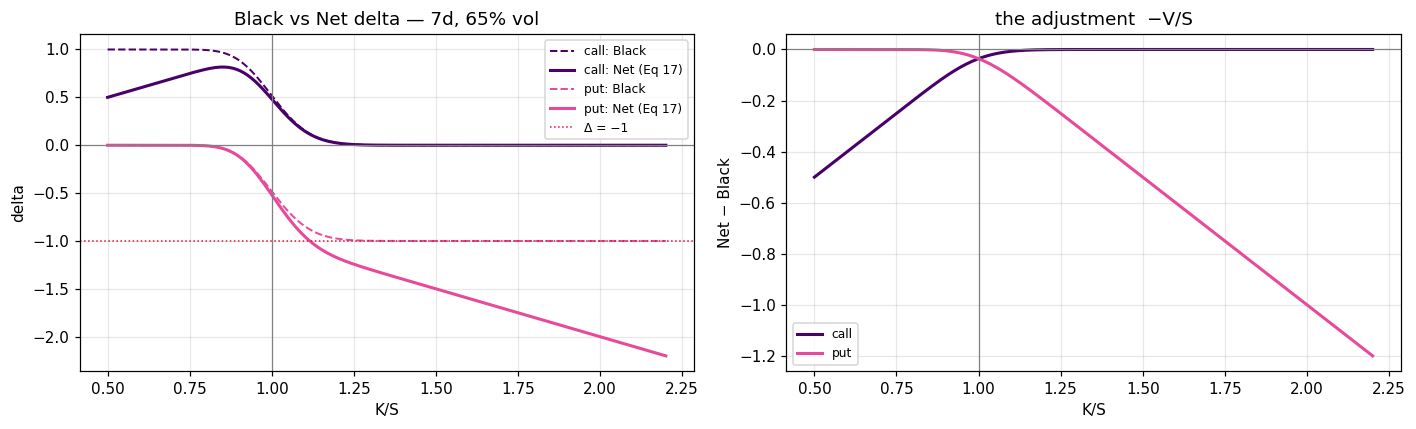

ATM: Black Δc +0.5179 -> Net +0.4821
Net CALL delta stays in [+0.000, +0.817] — bounded by 1.
Net PUT  delta reaches -2.200 — breaches -1 at K/S = 1.120, tends to -K.
A deep-ITM inverse put needs MORE than one perp per contract to hedge.


In [8]:
Kg = np.linspace(0.5, 2.2, 300)
T_, sig = 7/365, 0.65
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
for ot, nm, col in [("c","call",PALETTE[7]), ("p","put",PALETTE[3])]:
    bd  = gk_delta(1.0, Kg, T_, 0, 0, sig, ot)
    ind = inverse_delta(1.0, Kg, T_, 0, 0, sig, ot)
    ax[0].plot(Kg, bd, "--", color=col, lw=1.3, label=f"{nm}: Black")
    ax[0].plot(Kg, ind, "-", color=col, lw=2.0, label=f"{nm}: Net (Eq 17)")
    ax[1].plot(Kg, ind-bd, color=col, lw=2.0, label=nm)
ax[0].axhline(-1, color="crimson", lw=1.0, ls=":", label="Δ = −1")
for a in ax: a.axvline(1, color="grey", lw=.8); a.axhline(0, color="grey", lw=.8); a.legend(fontsize=8)
ax[0].set(xlabel="K/S", ylabel="delta", title="Black vs Net delta — 7d, 65% vol")
ax[1].set(xlabel="K/S", ylabel="Net − Black", title="the adjustment  −V/S")
plt.tight_layout(); plt.show()

ip = inverse_delta(1.0, Kg, T_, 0, 0, sig, "p"); ic = inverse_delta(1.0, Kg, T_, 0, 0, sig, "c")
print(f"ATM: Black Δc {gk_delta(1.,1.,T_,0,0,sig,'c'):+.4f} -> Net {inverse_delta(1.,1.,T_,0,0,sig,'c'):+.4f}")
print(f"Net CALL delta stays in [{ic.min():+.3f}, {ic.max():+.3f}] — bounded by 1.")
print(f"Net PUT  delta reaches {ip.min():+.3f} — breaches -1 at K/S = {Kg[ip < -1][0]:.3f}, tends to -K.")
print("A deep-ITM inverse put needs MORE than one perp per contract to hedge.")

> **Trial & error.** An early engine hedged with the plain Black delta. Every structure
> inherited a slow systematic drift that read as alpha one way and cost the other. It was
> neither — it was an unhedged $-V/S$. Puts are where it bites: the Net delta is unbounded
> below, so a put that goes deep ITM mid-week is under-hedged by up to 60% of notional.

<a id="sec6"></a>
## 6. The backtest state machine

`run_all_strategies` makes **one pass** over the option chunks and carries light
per-strategy state, so all 26 strategies cost roughly the wall-clock of one. Per snapshot:

```
        ┌── roll instant? ──────────────────────────────────────────┐
        │   _accrue      book hedge P&L + funding to this instant    │
        │   _settle      realise the expiring structure at intrinsic │
        │   _open        select legs, size to NAV, pay entry costs   │
        │   _rehedge     force=True — the book changed wholesale     │
        └────────────────────────────────────────────────────────────┘
        ┌── hedge hour? ────────────────────────────────────────────┐
        │   _accrue      perp P&L (Eq 26) + funding (Eq 29)          │
        │   _compute_book  target delta + mid mark  (pure)           │
        │   _rehedge     only if |drift| > band x NAV; charge 5bp    │
        └────────────────────────────────────────────────────────────┘
```

Three details that decide whether the NAV path is meaningful:

1. **`_accrue` is called *before* the book changes at a roll.** Otherwise the last holding
   period's hedge P&L is silently dropped. Funding accrues **pro-rata on elapsed time**, so
   it is correct whether called on the hourly grid or off-grid at a roll.
2. **`_compute_book` is pure** — no side effects — so the same function serves both hedging
   and marking, and the two can never disagree.
3. **The no-trade band is absolute, in coin units** (`band × NAV`), not relative to the
   position. A relative band is meaningless for delta-neutral structures: a straddle sits
   at target ≈ 0, so any relative band would trigger on every tick.

### Hedge P&L, demonstrated on the real perp

Eq 26: per-hour P&L = $(F_h - F_{h-1})/F_h \times \Delta^{\text{coin}}$. Note the
division by $F_h$ — the inverse contract's P&L is in coin, so it is a *return*, not a
price difference.

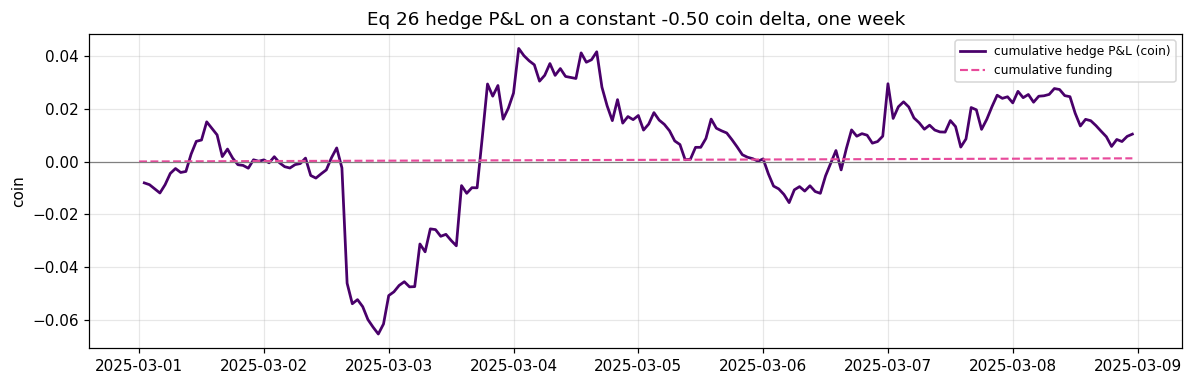

spot moved -0.60% over the week
hedge P&L  +0.01035 coin   funding +0.00120 coin


In [9]:
wk = perp["close"].loc["2025-03-01":"2025-03-08"].resample("1h").last().dropna()
delta_coin = -0.50                       # short 0.5 coin of net delta, held all week
pnl = (wk.diff() / wk) * delta_coin      # Eq 26, per hour
fund_rate = 0.0001                       # 1 bp / 8h, illustrative
funding = -np.sign(delta_coin) * abs(delta_coin) * fund_rate / 8 * np.ones(len(wk))

fig, ax = plt.subplots(figsize=(11, 3.6))
ax.plot(wk.index, pnl.cumsum(), color=PALETTE[7], lw=1.8, label="cumulative hedge P&L (coin)")
ax.plot(wk.index, np.cumsum(funding), color=PALETTE[3], lw=1.4, ls="--", label="cumulative funding")
ax.axhline(0, color="grey", lw=.8)
ax.set(ylabel="coin", title=f"Eq 26 hedge P&L on a constant {delta_coin:+.2f} coin delta, one week")
ax.legend(fontsize=8); plt.tight_layout(); plt.show()
print(f"spot moved {wk.iloc[-1]/wk.iloc[0]-1:+.2%} over the week")
print(f"hedge P&L  {pnl.sum():+.5f} coin   funding {funding.sum():+.5f} coin")

<a id="sec7"></a>
## 7. Execution, costs and funding

The paper's Assumption 5.1 charges a flat **50 bp of mid** on options and **5 bp of
notional** on the perp. We kept the perp figure and replaced the option one, because 50 bp
of mid is nowhere near the real cost of crossing a crypto option spread.

| | paper | this implementation |
|---|---|---|
| option entry | 50 bp on mid | **cross the real spread** — long buys the ask, short sells the bid |
| option marking | — | **mid, every hedge hour** |
| perp | 5 bp of traded notional | same |
| settlement | — | intrinsic coin payoff, no spread |
| explicit fee | — | `option_fee_bps`, default 0, **on top** of the spread |

Two consequences. The half-spread surfaces **automatically** in the NAV the instant a
position opens — bought at the ask, immediately worth mid. And marking at mid hourly makes
the NAV **continuous**, so daily vol, Sharpe and MaxDD are meaningful rather than
step-functions between rolls.

This matters a lot: the measured ETH option half-spread runs to several percent of premium,
against 5 bp for the perp. **Any strategy expressing a directional view through options is
paying ~11% round trip to say what the perp says for 5 bp.**

**Funding** (Eq 29) uses the realised hourly Deribit rate, with the correct sign: a long
perp **pays** when the rate is positive. A constant annualised fallback exists but the
recorded runs use the real series.

<a id="sec8"></a>
## 8. Accounting and position sizing

### Coin vs USD

| | **coin** (default, Eqs 39–44) | **USD** (Eqs 46–52) |
|---|---|---|
| funded in | ETH/BTC | USD |
| P&L accrues in | coin | coin, swapped to USD at the spot prevailing **when it accrues** |
| option P&L | $V(t)-V(t_0)$ | $S_t V(t) - S_{t_0} V(t_0)$ |
| sizing | $N = \Pi^{\text{coin}}$ | $N = \Pi^{\text{USD}}/S_t$ |
| keeps coin exposure? | **yes** — through realised profits | no |

Deribit is coin-native, so coin is the honest default. The USD book converts each coin
increment at the spot prevailing when it happened, which means the **FX move on the premium
between opening and settlement is part of the result**. The paper finds risk-adjusted
performance is close between the two (§5.2.4) — what really changes is **beta to the coin**.

### Sizing and compounding

Contracts = `qty × N` where `N` is the **current** Coin NAV, so the strategy
auto-compounds: $N(t_0) = \Pi(t_0)$. Sizing is always a contract count, which is a coin
quantity, under both accounting modes.

### What the results table reports

`roll_results.py` reproduces the paper's Table 1 layout:

- **Vol / Sharpe / Skew** — daily log-returns of the Coin NAV, annualised by √365, zero risk-free.
- **α_AN / β / R²** — OLS of the strategy's **weekly** log-returns on the coin's weekly
  log-returns; α annualised ×52, R² adjusted.
- **Benchmark row** — coin buy-and-hold, so β = 1, α = 0, R² = 1 by construction.

In [10]:
rng = np.random.default_rng(0)
idx = pd.date_range("2025-01-01", periods=365, freq="D", tz="UTC")
nav = pd.Series(np.exp(np.cumsum(rng.normal(0.0004, 0.02, 365))), index=idx)
pd.Series(RR._perf_stats(nav)).to_frame("synthetic NAV — metric definitions").round(4)

,synthetic NAV — metric definitions
total_return,-0.0786
cagr,-0.0788
ann_vol,0.3876
sharpe,-0.2119
max_dd,-0.3811
skew,-0.0565
final,0.9240


<a id="sec9"></a>
## 9. The relative-value engine: red cells

The second family. Every snapshot: calibrate a global eSSVI surface, re-price every listed
option, and flag a **red cell** where the model's Black-76 coin price falls **outside** that
row's own `[bid_price, ask_price]`.

It is a **price-space** test, not an IV-space one — deliberately, so it matches exactly what
a trader watching the live screen sees flagged. `signal.detect_red_cells` is the single
implementation shared by the screen, the GIF recorder and this engine.

```
theo > ask  -> 'buy'   (model says the market is too cheap)
theo < bid  -> 'sell'  (model says the market is too rich)
```

Mechanics: enter vega-sized ($1,000 vega) on each *new* red cell, delta-hedge the whole book
with the perp using Net Delta, exit when the signal nulls out, when a better opportunity
appears at the same strike+expiry, or at expiry into intrinsic. Full eSSVI recalibration
every 15 minutes, warm-started in between.

> **The trap this engine walks into, and why it is documented rather than hidden.** eSSVI
> has only 3 parameters per slice. On ETH chains that produces an **18–28% red-cell floor
> purely from functional form** — cells the model cannot fit, regardless of whether the
> market is mispriced. `_make_calibrator` therefore lets the model be swapped to RawSVI
> (5 params/slice) to measure how much of the "opportunity" is real. Most of it is not.

`invert=True` on the signal flags the same cells but swaps buy↔sell — a control that tests
whether direction or transaction costs drive the P&L. It deliberately does **not** flip
costs, since spread-crossing is paid either way.

In [11]:
print(inspect.getdoc(SIG.detect_red_cells)[:900])

Flag each row of a single-snapshot option dataframe as a "red cell":
the calibrated model's re-priced Black-76 coin price falls outside the
row's own [bid_price, ask_price] at `dp`-decimal precision. Same
definition as the live trading screen (streamlit_chain.py's `_styler`/
red-cell count, duplicated in chain_gif.py) — a price-space test, not an
IV-space one, so this stays consistent with what a trader watching the
live screen would actually see flagged.

`df` must be ONE snapshot (single file_timestamp), with the columns
`clean_df_pl`/`clean_bulk_parquet_chunked` produce: strike, option_type
('C'/'P'), t, k, underlying_price, bid_price, ask_price. `calib_result` is
the dict returned by any `calibrate_*`/`calibrate_*_update` function
(needs "_model", "expiries", "params").

Adds three columns to the returned frame:
    theo_price   model's Black-76 coin price at this row's own strike/t



<a id="sec10"></a>
## 10. Results **[archive]**

Running the catalogue needs `clean_chunks_full`. Recorded results:

### 10.1 Systematic strategies

Across the full 26-strategy catalogue, ETH and BTC, weekly and monthly rolls, coin and USD
accounting, realistic spread-crossing execution and realised funding:

**No variant produced a positive Sharpe ratio.**

That is not "every strategy lost money" — several had positive total returns. So did
holding the coin. The point of a delta-hedged vol strategy is that it should not need the
coin to go up, and none of them cleared that bar.

### 10.2 Relative value

The red-cell engine did not survive its own control. With the 18–28% structural red-cell
floor from eSSVI's functional form, most flagged "opportunities" were fitting error rather
than mispricing, and what remained did not cover the spread it had to cross to trade.

### 10.3 Reproducing them

```bash
python volatility_surface/backtest/run_roll.py \
    --options volatility_surface/notebooks/clean_chunks_full \
    --perp "2 - Data/parquets/eth_perp_1min_jan-jun2025.parquet" \
    --all --frequency weekly --coin ETH \
    --funding "2 - Data/parquets/eth_perp_funding_2024_2026.parquet" \
    --csv results_weekly.csv
```

`--regime all` adds one row per strategy × regime; `--accounting usd` switches the book.

<a id="sec11"></a>
## 11. Diagnosis I — the strategies traded direction, not volatility

Regressing weekly strategy returns on weekly coin returns:

| structure | β vs underlying | corr with spot |
|---|---|---|
| long call | **+0.13** | +0.81 |
| short call | **−0.13** | −0.80 |
| call-neutral (straddle, strangle, butterfly) | **−0.03** | — |

An hourly delta hedge removes delta. **It does not remove vanna** — the sensitivity of vega
to spot. A call-exposed structure keeps a residual directional exposure; the +0.81
correlation with spot makes that plain. The call-neutral structures come out at β = −0.03,
which confirms the mechanism rather than contradicting it.

Between hedges, the P&L a delta-hedged book picks up from vanna is approximately

$$\text{vanna} \times \Delta\sigma \times \Delta S$$

and $\Delta\sigma$ is driven by $\Delta S$ through the **spot–vol correlation** — §13.

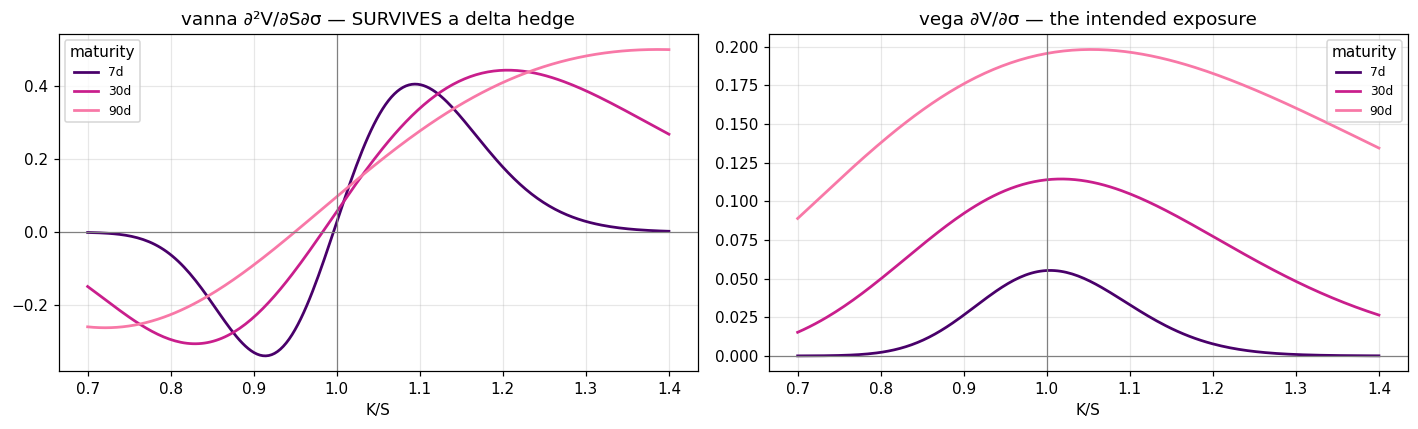

Vanna changes sign through the money and peaks in the wings — exactly where the
25D/10D structures sit. A delta hedge zeroes delta and leaves this untouched.


In [12]:
Kg = np.linspace(0.7, 1.4, 200)
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
for T_, lbl, col in [(7/365,"7d",PALETTE[7]), (30/365,"30d",PALETTE[4]), (90/365,"90d",PALETTE[2])]:
    ax[0].plot(Kg, gk_vanna(1.0, Kg, T_, 0, 0, 0.65), color=col, lw=1.8, label=lbl)
    ax[1].plot(Kg, gk_vega (1.0, Kg, T_, 0, 0, 0.65), color=col, lw=1.8, label=lbl)
for a, t in zip(ax, ["vanna ∂²V/∂S∂σ — SURVIVES a delta hedge", "vega ∂V/∂σ — the intended exposure"]):
    a.axvline(1, color="grey", lw=.8); a.axhline(0, color="grey", lw=.8)
    a.set(xlabel="K/S", title=t); a.legend(fontsize=8, title="maturity")
plt.tight_layout(); plt.show()
print("Vanna changes sign through the money and peaks in the wings — exactly where the")
print("25D/10D structures sit. A delta hedge zeroes delta and leaves this untouched.")

### 11.3 And there was no premium to harvest **[archive]**

| quantity | value |
|---|---|
| mean ATM implied vol (30d constant maturity) | 62.9% |
| mean subsequent realised vol | 63.7% |
| **premium (IV − RV)** | **−0.82%** |
| t-statistic | **−0.44** |
| 95% CI | [−4.5%, +2.8%] vol points |

**Negative, tiny, indistinguishable from zero.** Options were on average very slightly
*cheap*. That is the direct explanation for §10.1: the intended P&L source was absent.

The obvious timing rule fails too. "Enter when recent realised vol exceeds implied" needs
$RV_{\text{past}}-IV$ to predict $RV_{\text{future}}-IV$: correlation **+0.127**,
t = 1.25, $R^2$ **1.6%**. ETH realised vol *is* persistent (weekly autocorrelation +0.27) —
but implied vol already knows that.

<a id="sec12"></a>
## 12. Diagnosis II — which volatility does a hedger earn?

A delta-hedged position earns realised variance **at its hedging frequency**, not the
latent volatility. The engine hedges hourly, and the four estimators in
`vrp_signal.perp_variance` disagree by 3–6 vol points on exactly that distinction.

In [13]:
rv14 = SV.realised_vol_by_estimator(PERP, spot.index, V.ESTIMATORS, window_days=14, bar_freq="1h")
panel = rv14.copy(); panel["spot"] = spot
panel.attrs.update(rv_window=14, bar_freq="1h")
panel = panel.dropna(subset=["spot"])
print("Annualised vol, 14-day trailing window on 1h bars (vol points)")
SV.levels(panel)

Annualised vol, 14-day trailing window on 1h bars (vol points)


,n,mean,median,min,max,std,vs_close
series,,,,,,,
rv_close,793,64.60,62.87,25.08,116.00,17.85,0.00
rv_parkinson,794,67.75,64.82,23.26,128.22,20.12,3.14
rv_garman_klass,794,68.90,65.74,24.32,134.16,21.07,4.30
rv_rogers_satchell,794,70.66,66.74,24.65,146.16,22.68,6.06


`close` is the only estimator a discretely hedged position monetises. Parkinson,
Garman-Klass and Rogers-Satchell read the bar's high and low, so they see variation
happening **inside** the hedging interval.

`vs_close` is therefore the **discretisation loss**: an hourly hedger on ETH gives up
**3–6 vol points** of variation the underlying genuinely realised. It is not a constant
offset — near zero at ~50% vol, ~15 points at the peaks.

Read against §11.3: the theoretical premium was −0.82%, and the hedging frequency alone
costs several vol points. There was never a margin to work with.

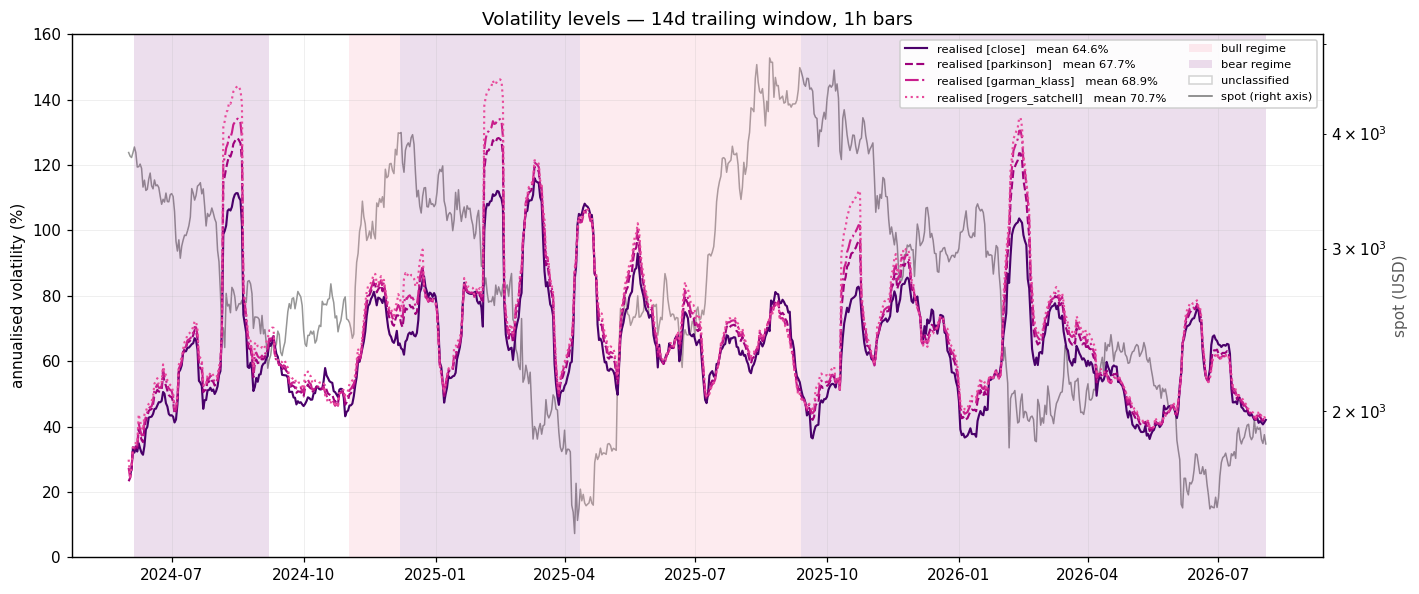

In [14]:
SV.plot_levels(panel, regimes=R.REGIMES, log_spot=True, implied=False, ylim=(0, 160))

<a id="sec13"></a>
## 13. Diagnosis III — the spot–vol correlation

The last unknown in §11: vanna P&L is (vanna) × (spot–vol correlation), and vanna we can
compute exactly. So how big is the correlation?

Measured from the perp alone, realised variance built per calendar day from **288 five-minute
returns** (non-overlapping, 8.3% relative standard error). Two things make the raw number
misleading, and both are handled:

- **Contamination.** $\mathrm{corr}(r_t, \Delta\log RV_t)$ puts $r_t$ *inside* $RV_t$,
  making it a realised-skewness estimator. Use $t{+}1$ instead.
- **Attenuation.** Daily RV is a noisy estimate of integrated variance; that noise is
  independent of the return and shrinks any correlation built on it. Monte Carlo on Heston
  paths with **known** ρ measured the shrinkage at a consistent **0.40×**, so the observed
  value is divided by it.

In [15]:
daily = LEV.daily_measures(LEV.intraday_returns(PERP, "5min"))
e1 = LEV.e1_correlations(daily)
display(e1[["rho", "n", "n_eff", "boot_lo", "boot_hi", "p_neff"]].round(4))

lh = LEV.lhar(daily)
print(f"LHAR (Corsi-Reno), R2={lh.attrs['r2']:.3f}, n={lh.attrs['n']}  "
      "-- rn_* are the NEGATIVE-return leverage terms")
display(lh.loc[["rn_d", "rn_w", "rp_d"]].round(4))

obs, lo_, hi_, ratio = -0.0851, -0.1491, -0.0162, 0.399
print(f"observed clean corr {obs:+.4f}  CI [{lo_:+.4f}, {hi_:+.4f}]   attenuation {ratio:.3f}")
print(f"IMPLIED rho = {obs/ratio:+.3f}   CI [{lo_/ratio:+.3f}, {hi_/ratio:+.3f}]"
      "     (equity indices: -0.60 to -0.80)")

,rho,n,n_eff,boot_lo,boot_hi,p_neff
measure,,,,,,
"CONTAMINATED corr(r_t, dlogRV_t) [= skewness]",-0.0932,793,638.1350,-0.1845,-0.0067,0.0182
"CLEAN corr(r_t, dlogRV_t+1)",-0.0851,793,1040.0940,-0.1483,-0.0176,0.0059
"CLEAN corr(r_t, dlogBV_t+1) [jump-robust]",-0.0624,793,1077.8866,-0.1252,0.0075,0.0403
"CLEAN corr(r_t, dlogMedRV_t+1) [jump-robust]",-0.0452,793,1111.8676,-0.1087,0.0252,0.1320


LHAR (Corsi-Reno), R2=0.376, n=772  -- rn_* are the NEGATIVE-return leverage terms


,coef,hac_se,t,p,ci_lo,ci_hi
rn_d,-8.7536,1.5191,-5.7625,0.0000,-11.7309,-5.7763
rn_w,-8.4002,3.8689,-2.1712,0.0299,-15.9831,-0.8172
rp_d,3.0886,1.1721,2.6350,0.0084,0.7913,5.3859


observed clean corr -0.0851  CI [-0.1491, -0.0162]   attenuation 0.399
IMPLIED rho = -0.213   CI [-0.374, -0.041]     (equity indices: -0.60 to -0.80)


$$\boxed{\rho_{\text{ETH}} \approx -0.21,\quad 95\%\ \text{CI}\ [-0.37,\ -0.04]}$$

The LHAR coefficient is the primary test: $\gamma_d = -8.75$, $t = -5.76$. A **−1% day
raises next-day realised variance 8.8%** against **3.1%** for a +1% day — down moves 2.8×
more. Real, negative, and roughly **one third the strength of an equity index**.

**Which closes the loop on §11.** Residual beta = vanna × ρ. Vanna is large in the wings
where the 25Δ/10Δ structures sit, but ρ is only −0.21 and unstable, so the vanna edge is
thin — thin enough that ±0.13 of unintended directional beta is what survives, and it is
not compensation for anything.

Full methodology, robustness and the Monte Carlo calibration table are in
`results/summary.md` and `results/montecarlo.md`; the module is
`backtest/leverage.py`.

<a id="sec14"></a>
## 14. Regimes, and a look-ahead trap

`roll_results.sharpe_by_regime` / `regime_table` split results by market state. That is
only meaningful if the state was knowable **at the time**.

### ⚠️ `roll_engine.REGIMES` is not

In [16]:
src = inspect.getsource(R)
print(src[src.index("# Market regimes"):src.index("def _to_ms")].strip()[:1000])

# Market regimes
# --------------------------------------------------------------------------- #
#: Hand-labelled ETH regimes over the 2024-2026 dataset, as (start, end) UTC
#: dates. Deliberately NOT derived from the data: the paper's own regime split
#: (Fig 8/9) sorts monthly returns and cuts the tails at 16%, which is circular
#: when the question is "does this strategy survive a regime it did not fit to".
#: These are the user's own reading of the market and are meant to be edited.
#: Note the gaps (e.g. 2024-09-07 -> 2024-11-02) — those months belong to
#: neither camp and are simply excluded from a regime run.
REGIMES: dict[str, tuple[str, str]] = {
    "bear1": ("2024-06-05", "2024-09-07"),
    "bear2": ("2024-12-07", "2025-04-12"),
    "bear3": ("2025-09-13", "2026-08-03"),
    "bull1": ("2024-11-02", "2024-12-07"),
    "bull2": ("2025-04-12", "2025-09-13"),
}


Five date ranges **hand-drawn from the finished price chart** — `bear2` runs local top to
local bottom. Any statement of the form "this strategy works in bear markets" built on
these is circular: nothing could have known the label at the time.

They stay useful as chart **shading** (which is how §12 uses them). For statistics we need
a causal definition.

### The causal replacements

1. **`leverage.causal_regimes`** — trailing drawdown from a running 90-day max. Past
   information only.
2. **`regime_hmm.walk_forward_states`** — a Gaussian HMM refitted on an expanding window,
   with a strict separation the module enforces by naming:

   - **filtered** $P(s_t \mid x_1..x_t)$ — only the past. Tradeable.
   - **smoothed** $P(s_t \mid x_1..x_T)$ — the whole sample. **Descriptive only.**

   `hmmlearn.predict()` (Viterbi) is *smoothed*. A backtest on it looks excellent and means
   nothing. The module exposes `smoothed_states` under a name that cannot be used by
   accident.

The HMM works as a classifier — 77% state persistence, 98.8% walk-forward accuracy. But the
premium is **zero in both states**, so there is nothing to switch between. And the module's
own docstring makes the sharper point: switching between long-call and short-call
structures on a state signal is directional timing wearing an options costume, paying an
~11% option spread to express what the perp expresses for 5 bp.

In [17]:
reg = LEV.causal_regimes(spot)
print("causal regimes (trailing 90-day drawdown from running max):")
print(reg.value_counts().to_string())
print("\nleverage effect pooled by causal regime:")
LEV.by_regime(daily, reg).round(4)

causal regimes (trailing 90-day drawdown from running max):
regime_causal
drawdown     434
neutral      264
near-high     96

leverage effect pooled by causal regime:


,n,mean_rv_ann,sv_ratio,sv_se,sv_t,corr_clean,n_eff,boot_lo,boot_hi
regime,,,,,,,,,
drawdown,434,0.6567,-0.0036,0.0090,-0.3954,-0.1204,604.7080,-0.1982,-0.0405
near-high,96,0.6309,0.0735,0.0164,4.4876,-0.2060,67.2967,-0.4195,0.0303
neutral,264,0.5642,-0.0284,0.0125,-2.2732,0.0059,263.0000,-0.0993,0.1124


`near-high` reads −0.206 against `drawdown` −0.120 — but `near-high` has
$n_{\text{eff}} = 67$ and a CI of $[-0.42, +0.03]$. 794 days with a vol half-life of ~3
weeks contains perhaps **4–6 independent macro episodes**. **There is not enough
independent variation to distinguish regime correlations, and we do not claim one.**

<a id="sec15"></a>
## 15. Trials & errors

1. **Hedging an inverse option with the plain Black delta.** Missing the $-V/S$ adjustment
   (Eq 17) gave every structure a slow systematic drift that read as alpha one way and cost
   the other. **The numeraire is part of the instrument.**

2. **Charging a flat 50 bp on mid.** The paper's Assumption 5.1 understates crypto option
   execution by an order of magnitude. Crossing the real spread and marking at mid moved
   several strategies from "marginal" to "clearly negative" — and made the NAV continuous
   enough for Sharpe and MaxDD to mean anything.

3. **A relative no-trade band.** Delta-neutral structures sit at target ≈ 0, so a band
   defined relative to the position triggers on every tick. It has to be absolute, in coin
   units, scaled by NAV.

4. **Accruing after the book changed.** Calling `_accrue` after a roll silently dropped the
   last holding period's hedge P&L. Ordering is load-bearing in a state machine.

5. **Mistaking a fitting floor for opportunity.** eSSVI's 3 parameters per slice produce an
   18–28% red-cell rate on ETH chains from functional form alone. Most flagged
   "mispricings" were the model, not the market.

6. **Smoothed HMM states.** `hmmlearn.predict()` is Viterbi. A backtest on it looks
   excellent and means nothing.

7. **A hindsight-labelled regime input.** `REGIMES` was hand-drawn peak-to-trough from the
   finished chart. Look-ahead arrives through the inputs you didn't think of as estimates.

8. **Interpreting a correlation before calibrating the estimator.** Weeks reading a rolling
   spot–vol correlation that Monte Carlo later showed to be attenuated 2.5× and, at n = 90,
   unable to distinguish −0.2 from zero. **The simulation should have come first.**

9. **A library function that hijacked the backend.** `matplotlib.use("Agg")` inside a
   plotting helper switched the whole kernel headless, silently swallowing every figure.

<a id="sec16"></a>
## 16. Conclusion

**Why the strategies failed, in one paragraph.** There was no premium to harvest
(−0.82%, t = −0.44), so the intended P&L source was absent. Hedging hourly gives up a
further 3–6 vol points of realised variation to discretisation. What remained was a
residual directional exposure through vanna (β = ±0.13, spot correlation ±0.80), driven by
a spot–vol correlation that is real but weak (ρ ≈ −0.21) and unstable. Against all of that,
execution costs an ~11% option spread where the perp costs 5 bp. **The strategies paid a
large, certain cost to express a small, uncertain edge in the most expensive available
instrument.**

**What the project produced that is worth keeping:**

- A faithful, reusable implementation of Lucic & Sepp's systematic backtester, with more
  realistic execution than the paper and both accounting conventions.
- The **Net Delta** hedge ratio wired through every engine — the one implementation detail
  that most changes results.
- A measured **discretisation loss** of 3–6 vol points for hourly hedging, state-dependent.
- **ρ_ETH ≈ −0.21, CI [−0.37, −0.04]** — the first defensible spot–vol number for this book,
  with a Monte Carlo calibration behind it.
- A causal regime toolkit to replace the hand-labelled one.

**What we cannot say from this data:**

- Whether options *price* the leverage effect correctly. That needs the implied side —
  $\partial\sigma_{ATM}/\partial\log F$, the skew-stickiness ratio, and the
  implied-versus-realised ρ gap, which is the skew risk premium. **The highest-value
  remaining measurement**, and §13 gives it a baseline.
- Whether any of this is stable out of sample. One 26-month window cannot separate "ETH"
  from "2024–2026".

**Next steps, in order of expected value:**

1. Build the constant-maturity, constant-moneyness IV surface; regress $\Delta IV$ on
   $\Delta\log F$; compare the implied ρ to the −0.21 measured here. If implied is
   materially more negative, the skew premium is the tradeable object — not the level.
2. Re-run the roll strategies with **vanna hedged explicitly**, now that the correlation
   driving it is quantified. This is the one modification with a measured rationale.
3. Repeat §13 on BTC. Sign agreement across two assets would be worth more than another ETH
   robustness check.

---

> **The lesson.** Every wrong answer here came from a component that could not see what it
> was being asked about — a hedge ratio missing a numeraire term, a cost model an order of
> magnitude too small, a band defined against the wrong quantity, a fitting floor mistaken
> for opportunity, a label that encoded the future. None announced itself as an error. They
> all produced plausible numbers.

*End of summary.*